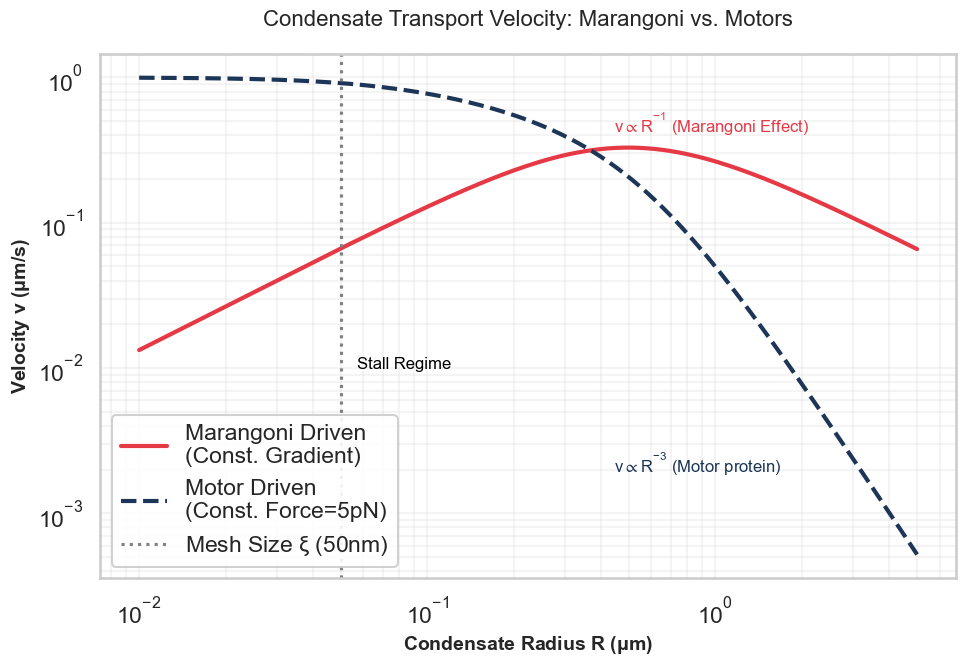

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import seaborn as sns

# --- 1. 参数定义 (SI Units) ---
eta_sol = 0.01        # 细胞质溶剂粘度，生物大分子尺度基础数据 (Pa*s)
xi = 50e-9           # 网孔尺寸 (m)
G0 = 200          # 骨架弹性模量 (Pa)
tau = 0.1          # 骨架松弛时间 (s)

# Marangoni 参数
grad_sigma = 4     # 表面张力梯度 (N/m^2 or Pa) -> 200uN/m / 50um

# Motor 参数
N_motor = 1          # 恒定马达数量
F_stall_single = 5e-12 # 单个马达失速力 (N)
F_stall_total = N_motor * F_stall_single
v_motor_max = 1e-6   # 马达最大速度 (m/s)

# 尺寸范围 R (从 10nm 到 5um)
R_array = np.logspace(-8, -5.3, 200) # approx 10nm to 5um

# --- 2. 阻力函数定义 ---
def drag_force(v, R):
    # Poroelastic term: 6 * pi * eta * (R/xi)^2 * R * v
    # Simplified: 6 * pi * eta * R^3 * v / xi^2
    if R>=xi:
        f_poro = 6 * np.pi * eta_sol * (R**3 / xi**2) * v
    else:
        f_poro = 6 * np.pi * eta_sol * R*v
    
    # Viscoelastic Rearrangement term: G0 * R^2 * (1 - exp(-v*tau/R))
    # Note: avoid divide by zero if R is tiny, but R array is safe
    f_visco = G0 * (R**2) * (1 - np.exp(-v * tau / R))
    
    return f_poro + f_visco

# --- 3. 求解 Marangoni 速度 ---
v_marangoni = []
for R in R_array:
    # Drive: F_M = 2 * pi * R^2 * grad_sigma
    # Equation: Drive - Drag(v) = 0
    drive = 2 * np.pi * (R**2) * grad_sigma
    
    def func_m(v):
        return drive - drag_force(v, R)
    
    # 数值求解，搜索范围 0 到 1 m/s (足够大)
    try:
        v_sol = brentq(func_m, 0, 1.0)
    except ValueError:
        v_sol = 0.0 # Should not happen given physics
    v_marangoni.append(v_sol)

v_marangoni = np.array(v_marangoni)

# --- 4. 求解 Motor 速度 ---
v_motor = []
for R in R_array:
    # Drive: F_motor(v) = F_stall_total * (1 - v/v_max)
    # Equation: Drive(v) - Drag(v) = 0
    
    def func_motor(v):
        # 物理限制：v 不能超过 v_max，也不能小于 0
        if v < 0: return F_stall_total # limit case
        if v > v_motor_max: return -drag_force(v, R) # drive is 0 or negative
        
        drive = F_stall_total * (1 - v / v_motor_max)
        return drive - drag_force(v, R)
    
    try:
        v_sol = brentq(func_motor, 0, v_motor_max)
    except ValueError:
        v_sol = 0.0
    v_motor.append(v_sol)

v_motor = np.array(v_motor)

# --- 5. 绘图 ---
sns.set_context("talk")
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(10, 7))

# 转换单位方便阅读 (R in um, v in nm/s or um/s)
R_um = R_array * 1e6
v_marangoni_ums = v_marangoni * 1e6
v_motor_ums = v_motor * 1e6

# 绘制曲线
ax.plot(R_um, v_marangoni_ums, label='Marangoni Driven\n(Const. Gradient)', 
        color='#E63946', linewidth=3)
ax.plot(R_um, v_motor_ums, label='Motor Driven\n(Const. Force=5pN)', 
        color='#1D3557', linewidth=3, linestyle='--')

# 标注网孔尺寸 xi
ax.axvline(x=xi*1e6, color='gray', linestyle=':', label=r'Mesh Size $\xi$ (50nm)')

# 坐标轴设置
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'Condensate Radius $R$ ($\mu m$)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'Velocity $v$ ($\mu m/s$)', fontsize=14, fontweight='bold')
ax.set_title('Condensate Transport Velocity: Marangoni vs. Motors', fontsize=16, pad=20)

# 图例与网格
ax.legend(loc='lower left', frameon=True, framealpha=0.9)
ax.grid(True, which="both", ls="-", alpha=0.2)

# 添加注释
ax.text(0.6, 0.85, r'$v \propto R^{-1}$ (Marangoni Effect)', 
        transform=ax.transAxes, color='#E63946', fontsize=12)
ax.text(0.3, 0.4, r'Stall Regime', 
        transform=ax.transAxes, color='black', fontsize=12)
ax.text(0.6, 0.2, r'$v \propto R^{-3}$ (Motor protein)', 
        transform=ax.transAxes, color='#1D3557', fontsize=12)

plt.tight_layout()

# Save/Show
plt.savefig('condensate_dynamics.svg', format='svg')
plt.show()

In [11]:
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import brentq

# --- 1. 物理参数定义 ---
KB_T = 4.11e-21      # Boltzmann constant * T (300K)
eta_sol = 0.1        # 细胞质溶剂粘度 (Pa*s)
xi = 50e-9           # 网孔尺寸 (m)
G0 = 200.0           # 骨架弹性模量 (Pa)
tau = 0.1            # 骨架松弛时间 (s)

# Marangoni 参数
grad_sigma = 4.0     # 表面张力梯度 (Pa)

# Motor 参数
N_motor = 1          # 恒定马达数量
F_stall_single = 5e-12 
F_stall_total = N_motor * F_stall_single
v_motor_max = 0.5e-6 

# 时间限制
TIME_LIMIT_S = 1000.0

# Z轴范围设定 (User Request: 10^0 to 10^8)
Z_MIN_AXIS = 0  # 10^0 = 1s
Z_MAX_AXIS = 8  # 10^8s
Z_FLOOR = 0     # 投影平面放置在 Z=0 (1s) 处

# --- 2. 坐标网格定义 ---
num_points = 120
R_vals = np.logspace(-8, -5.3, num_points) # 10nm - 5um
# Distance x: 0.5um to 100um (User Request)
x_vals = np.logspace(np.log10(0.5e-6), np.log10(100e-6), num_points) 

R_mesh, x_mesh = np.meshgrid(R_vals, x_vals)

# --- 3. 核心物理计算函数 ---
def drag_force(v, R):
    if R >= xi:
        f_poro = 6 * np.pi * eta_sol * (R**3 / xi**2) * v
    else:
        f_poro = 6 * np.pi * eta_sol * R * v
    
    if v == 0:
        f_visco = 0
    else:
        f_visco = G0 * (R**2) * (1 - np.exp(-v * tau / R))
    return f_poro + f_visco

def get_friction_coefficient(R):
    if R >= xi:
        gamma_poro = 6 * np.pi * eta_sol * (R**3 / xi**2)
    else:
        gamma_poro = 6 * np.pi * eta_sol * R
    gamma_visco = G0 * R * tau
    return gamma_poro + gamma_visco

# --- 4. 数据计算 ---
v_mar_list = []
v_mot_list = []
D_diff_list = []

for R in R_vals:
    # Marangoni
    drive_m = 2 * np.pi * (R**2) * grad_sigma
    def func_m(v): return drive_m - drag_force(v, R)
    try: v_m = brentq(func_m, 0, 2.0)
    except: v_m = 1e-20
    v_mar_list.append(v_m)
    
    # Motor
    def func_mot(v):
        if v < 0: return F_stall_total
        if v > v_motor_max: return -drag_force(v, R)
        drive = F_stall_total * (1 - v / v_motor_max)
        return drive - drag_force(v, R)
    try:
        if drag_force(0, R) > F_stall_total: v_mot = 0
        else:
             try: v_mot = brentq(func_mot, 0, v_motor_max)
             except ValueError: v_mot = 1e-20
    except: v_mot = 1e-20
    if v_mot < 1e-15: v_mot = 1e-20
    v_mot_list.append(v_mot)
    
    # Diffusion
    gamma = get_friction_coefficient(R)
    D = KB_T / gamma
    D_diff_list.append(D)

v_mar_arr = np.array(v_mar_list)
v_mot_arr = np.array(v_mot_list)
D_diff_arr = np.array(D_diff_list)

# --- 5. 时间曲面计算 Z = log10(Time) ---
T_mar = x_mesh / v_mar_arr[None, :] 
T_mot = x_mesh / v_mot_arr[None, :]
T_diff = (x_mesh**2) / (4 * D_diff_arr[None, :])

Z_mar = np.log10(T_mar)
Z_mot = np.log10(T_mot)
Z_diff = np.log10(T_diff)

# Clip surfaces for visualization (so they don't break the graph scaling)
# Clipping lower bound to Z_FLOOR to keep graph clean, upper to Z_MAX_AXIS
Z_mar_clip = np.clip(Z_mar, -2, Z_MAX_AXIS + 1)
Z_mot_clip = np.clip(Z_mot, -2, Z_MAX_AXIS + 1)
Z_diff_clip = np.clip(Z_diff, -2, Z_MAX_AXIS + 1)

# --- 6. 底部叠加投影图 (Overlay Projection Map) ---
# Logic: Additive color mixing based on binary flags
# Bit 0: Diffusion valid (Value 1) -> Blue
# Bit 1: Motor valid (Value 2) -> Green
# Bit 2: Marangoni valid (Value 4) -> Red

Z_floor_color = np.zeros_like(Z_diff) # Initialize with 0 (None)
Z_floor_surface = np.full_like(Z_diff, Z_FLOOR) # Place at Z=0

for i in range(num_points): # x index
    for j in range(num_points): # R index
        val = 0
        # Check Diffusion
        if T_diff[i, j] <= TIME_LIMIT_S:
            val += 1
        # Check Motor
        if T_mot[i, j] <= TIME_LIMIT_S:
            val += 2
        # Check Marangoni
        if T_mar[i, j] <= TIME_LIMIT_S:
            val += 4
            
        Z_floor_color[i, j] = val

# Define Discrete Colorscale for 0-7
# 0: None (Transparent/White)
# 1: Diff (Blue)
# 2: Mot (Green)
# 3: Diff+Mot (Cyan)
# 4: Mar (Red)
# 5: Diff+Mar (Purple - rare)
# 6: Mot+Mar (Yellow/Orange)
# 7: All (White/Gray)

# Normalize values to [0, 1] for colorscale: Value/7
colorscale_overlay = [
    [0.0, 'rgba(255,255,255,0)'],     # 0: None (Transparent)
    [0.142, 'rgba(255,255,255,0)'],
    
    [0.142, 'rgb(100, 100, 255)'],    # 1: Blue (Diff)
    [0.285, 'rgb(100, 100, 255)'],
    
    [0.285, 'rgb(50, 200, 50)'],      # 2: Green (Mot)
    [0.428, 'rgb(50, 200, 50)'],
    
    [0.428, 'rgb(0, 200, 200)'],      # 3: Cyan (Diff + Mot)
    [0.571, 'rgb(0, 200, 200)'],
    
    [0.571, 'rgb(255, 50, 50)'],      # 4: Red (Mar)
    [0.714, 'rgb(255, 50, 50)'],
    
    [0.714, 'rgb(200, 50, 200)'],     # 5: Purple (Diff + Mar)
    [0.857, 'rgb(200, 50, 200)'],
    
    [0.857, 'rgb(255, 200, 0)'],      # 6: Yellow (Mot + Mar)
    [0.999, 'rgb(255, 200, 0)'],
    
    [0.999, 'rgb(200, 200, 200)'],    # 7: Gray/White (All)
    [1.0, 'rgb(200, 200, 200)']
]

# --- 7. Plotly 3D 绘图 ---
R_disp = R_vals * 1e6 # um
x_disp = x_vals * 1e6 # um

fig = go.Figure()

# Grid style
contours_style = {
    "x": {"show": True, "start": np.log10(R_disp[0]), "end": np.log10(R_disp[-1]), "size": 0.5, "color": "white", "width": 1},
    "y": {"show": True, "start": np.log10(x_disp[0]), "end": np.log10(x_disp[-1]), "size": 0.5, "color": "white", "width": 1}
}

# 1. Diffusion Surface
fig.add_trace(go.Surface(
    z=Z_diff_clip, x=R_disp, y=x_disp,
    name='Passive Diffusion', colorscale='Blues',
    cmin=0, cmax=8, opacity=0.3, showscale=False, contours=contours_style,
    hovertemplate="Diffusion<br>Time: 10^%{z:.2f} s"
))

# 2. Motor Surface
fig.add_trace(go.Surface(
    z=Z_mot_clip, x=R_disp, y=x_disp,
    name='Motor Transport', colorscale='Greens',
    cmin=0, cmax=8, opacity=0.7, showscale=False, contours=contours_style,
    hovertemplate="Motor<br>Time: 10^%{z:.2f} s"
))

# 3. Marangoni Surface
fig.add_trace(go.Surface(
    z=Z_mar_clip, x=R_disp, y=x_disp,
    name='Marangoni', colorscale='Reds',
    cmin=0, cmax=8, opacity=0.6, showscale=False, contours=contours_style,
    hovertemplate="Marangoni<br>Time: 10^%{z:.2f} s"
))

# 4. Floor Projection (Additive Colors)
fig.add_trace(go.Surface(
    z=Z_floor_surface, x=R_disp, y=x_disp,
    surfacecolor=Z_floor_color,
    colorscale=colorscale_overlay,
    cmin=0, cmax=7,
    showscale=False, opacity=0.9,
    name='Valid Regions (<1000s)',
    hovertemplate="<b>Region Map</b><br>Overlap of valid mechanisms"
))

# 5. 1000s Limit Plane (at Z=3)
plane_R, plane_x = np.meshgrid(np.linspace(R_disp[0], R_disp[-1], 2), np.linspace(x_disp[0], x_disp[-1], 2))
plane_z_3 = np.full_like(plane_R, np.log10(1000))
fig.add_trace(go.Surface(
    z=plane_z_3, x=plane_R, y=plane_x,
    name='1000s Threshold', colorscale=[[0, 'black'], [1, 'black']],
    opacity=0.1, showscale=False, hoverinfo='skip'
))

# Layout
fig.update_layout(
    title='<b>Transport Mechanism Landscape & Validity Overlap</b><br>Floor Colors: Blue(Diff), Green(Motor), Red(Marangoni) & Mixes',
    scene=dict(
        xaxis=dict(title='Radius R (μm)', type='log'),
        yaxis=dict(title='Distance x (μm)', type='log', range=[np.log10(0.5), np.log10(100)]),
        zaxis=dict(title='Time t (log10 s)', range=[Z_MIN_AXIS, Z_MAX_AXIS]), # 10^0 to 10^8
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.5)),
        aspectmode='manual', aspectratio=dict(x=1, y=1, z=0.7)
    ),
    width=1000, height=800,
    margin=dict(l=0, r=0, b=0, t=50)
)

# Legend annotation
fig.add_annotation(text="<b>Floor Legend (<1000s):</b><br>Cyan = Diff + Motor<br>Yellow = Motor + Marangoni<br>Grey = All Three<br>Blue/Green/Red = Only One",
                   xref="paper", yref="paper", x=0.02, y=0.02, showarrow=False, align="left", bgcolor="rgba(255,255,255,0.8)")

fig.write_html("Transport_Landscape_Overlap.html")
fig.show()

In [15]:
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import brentq

# --- 1. 物理参数定义 ---
KB_T = 4.11e-21      # Boltzmann constant * T (300K)
eta_sol = 0.1        # 细胞质溶剂粘度 (Pa*s)
xi = 50e-9           # 网孔尺寸 (m)
G0 = 200.0           # 骨架弹性模量 (Pa)
tau = 0.1            # 骨架松弛时间 (s)

# Marangoni 参数
grad_sigma = 4.0     # 表面张力梯度 (Pa)

# Motor 参数
N_motor = 1          # 恒定马达数量
F_stall_single = 5e-12 
F_stall_total = N_motor * F_stall_single
v_motor_max = 0.5e-6 

# 时间限制
TIME_LIMIT_S = 1000.0

# Z轴范围设定 (User Request: 10^0 to 10^8)
Z_MIN_AXIS = 0  # 10^0 = 1s
Z_MAX_AXIS = 8  # 10^8s
Z_FLOOR = 0     # 投影平面放置在 Z=0 (1s) 处

# --- 2. 坐标网格定义 ---
num_points = 120
R_vals = np.logspace(-8, -5.3, num_points) # 10nm - 5um
# Distance x: 0.5um to 100um (User Request)
x_vals = np.logspace(np.log10(0.5e-6), np.log10(100e-6), num_points) 

R_mesh, x_mesh = np.meshgrid(R_vals, x_vals)

# --- 3. 核心物理计算函数 ---
def drag_force(v, R):
    if R >= xi:
        f_poro = 6 * np.pi * eta_sol * (R**3 / xi**2) * v
    else:
        f_poro = 6 * np.pi * eta_sol * R * v
    
    if v == 0:
        f_visco = 0
    else:
        f_visco = G0 * (R**2) * (1 - np.exp(-v * tau / R))
    return f_poro + f_visco

def get_friction_coefficient(R):
    if R >= xi:
        gamma_poro = 6 * np.pi * eta_sol * (R**3 / xi**2)
    else:
        gamma_poro = 6 * np.pi * eta_sol * R
    gamma_visco = G0 * R * tau
    return gamma_poro + gamma_visco

# --- 4. 数据计算 ---
v_mar_list = []
v_mot_list = []
D_diff_list = []

for R in R_vals:
    # Marangoni
    drive_m = 2 * np.pi * (R**2) * grad_sigma
    def func_m(v): return drive_m - drag_force(v, R)
    try: v_m = brentq(func_m, 0, 2.0)
    except: v_m = 1e-20
    v_mar_list.append(v_m)
    
    # Motor
    def func_mot(v):
        if v < 0: return F_stall_total
        if v > v_motor_max: return -drag_force(v, R)
        drive = F_stall_total * (1 - v / v_motor_max)
        return drive - drag_force(v, R)
    try:
        if drag_force(0, R) > F_stall_total: v_mot = 0
        else:
             try: v_mot = brentq(func_mot, 0, v_motor_max)
             except ValueError: v_mot = 1e-20
    except: v_mot = 1e-20
    if v_mot < 1e-15: v_mot = 1e-20
    v_mot_list.append(v_mot)
    
    # Diffusion
    gamma = get_friction_coefficient(R)
    D = KB_T / gamma
    D_diff_list.append(D)

v_mar_arr = np.array(v_mar_list)
v_mot_arr = np.array(v_mot_list)
D_diff_arr = np.array(D_diff_list)

# --- 5. 时间曲面计算 Z = log10(Time) ---
T_mar = x_mesh / v_mar_arr[None, :] 
T_mot = x_mesh / v_mot_arr[None, :]
T_diff = (x_mesh**2) / (4 * D_diff_arr[None, :])

Z_mar = np.log10(T_mar)
Z_mot = np.log10(T_mot)
Z_diff = np.log10(T_diff)

# Clip surfaces for visualization (so they don't break the graph scaling)
# Clipping lower bound to Z_FLOOR to keep graph clean, upper to Z_MAX_AXIS
Z_mar_clip = np.clip(Z_mar, -2, Z_MAX_AXIS + 1)
Z_mot_clip = np.clip(Z_mot, -2, Z_MAX_AXIS + 1)
Z_diff_clip = np.clip(Z_diff, -2, Z_MAX_AXIS + 1)

# --- 6. 底部叠加投影图 (Overlay Projection Map) ---
# Logic: Additive color mixing based on binary flags
# Bit 0: Diffusion valid (Value 1) -> Blue
# Bit 1: Motor valid (Value 2) -> Green
# Bit 2: Marangoni valid (Value 4) -> Red

Z_floor_color = np.zeros_like(Z_diff) # Initialize with 0 (None)
Z_floor_surface = np.full_like(Z_diff, Z_FLOOR) # Place at Z=0

for i in range(num_points): # x index
    for j in range(num_points): # R index
        val = 0
        # Check Diffusion
        if T_diff[i, j] <= TIME_LIMIT_S:
            val += 1
        # Check Motor
        if T_mot[i, j] <= TIME_LIMIT_S:
            val += 2
        # Check Marangoni
        if T_mar[i, j] <= TIME_LIMIT_S:
            val += 4
            
        Z_floor_color[i, j] = val

# Define Discrete Colorscale for 0-7
# 0: None (Transparent/White)
# 1: Diff (Blue)
# 2: Mot (Green)
# 3: Diff+Mot (Cyan)
# 4: Mar (Red)
# 5: Diff+Mar (Purple - rare)
# 6: Mot+Mar (Yellow/Orange)
# 7: All (White/Gray)

# Normalize values to [0, 1] for colorscale: Value/7
colorscale_overlay = [
    [0.0, 'rgba(255,255,255,0)'],     # 0: None (Transparent)
    [0.142, 'rgba(255,255,255,0)'],
    
    [0.142, 'rgb(100, 100, 255)'],    # 1: Blue (Diff)
    [0.285, 'rgb(100, 100, 255)'],
    
    [0.285, 'rgb(50, 200, 50)'],      # 2: Green (Mot)
    [0.428, 'rgb(50, 200, 50)'],
    
    [0.428, 'rgb(0, 200, 200)'],      # 3: Cyan (Diff + Mot)
    [0.571, 'rgb(0, 200, 200)'],
    
    [0.571, 'rgb(255, 50, 50)'],      # 4: Red (Mar)
    [0.714, 'rgb(255, 50, 50)'],
    
    [0.714, 'rgb(200, 50, 200)'],     # 5: Purple (Diff + Mar)
    [0.857, 'rgb(200, 50, 200)'],
    
    [0.857, 'rgb(255, 200, 0)'],      # 6: Yellow (Mot + Mar)
    [0.999, 'rgb(255, 200, 0)'],
    
    [0.999, 'rgb(200, 200, 200)'],    # 7: Gray/White (All)
    [1.0, 'rgb(200, 200, 200)']
]

# --- 7. Plotly 3D 绘图 ---
R_disp = R_vals * 1e6 # um
x_disp = x_vals * 1e6 # um

fig = go.Figure()

# Grid style
contours_style = {
    "x": {"show": True, "start": np.log10(R_disp[0]), "end": np.log10(R_disp[-1]), "size": 0.5, "color": "white", "width": 1},
    "y": {"show": True, "start": np.log10(x_disp[0]), "end": np.log10(x_disp[-1]), "size": 0.5, "color": "white", "width": 1}
}

# 1. Diffusion Surface
fig.add_trace(go.Surface(
    z=Z_diff_clip, x=R_disp, y=x_disp,
    name="<span style='color: rgb(100, 100, 255)'>Passive Diffusion</span>", # Colored Text
    colorscale='Blues',
    cmin=0, cmax=8, opacity=0.3, showscale=False, contours=contours_style,
    hovertemplate="Diffusion<br>Time: 10^%{z:.2f} s"
))

# 2. Motor Surface
fig.add_trace(go.Surface(
    z=Z_mot_clip, x=R_disp, y=x_disp,
    name="<span style='color: rgb(50, 200, 50)'>Motor Transport</span>", # Colored Text
    colorscale='Greens',
    cmin=0, cmax=8, opacity=0.7, showscale=False, contours=contours_style,
    hovertemplate="Motor<br>Time: 10^%{z:.2f} s"
))

# 3. Marangoni Surface
fig.add_trace(go.Surface(
    z=Z_mar_clip, x=R_disp, y=x_disp,
    name="<span style='color: rgb(255, 50, 50)'>Marangoni</span>", # Colored Text
    colorscale='Reds',
    cmin=0, cmax=8, opacity=0.6, showscale=False, contours=contours_style,
    hovertemplate="Marangoni<br>Time: 10^%{z:.2f} s"
))

# 4. Floor Projection (Additive Colors)
fig.add_trace(go.Surface(
    z=Z_floor_surface, x=R_disp, y=x_disp,
    surfacecolor=Z_floor_color,
    colorscale=colorscale_overlay,
    cmin=0, cmax=7,
    showscale=False, opacity=0.9,
    name='Valid Regions (<1000s)',
    hovertemplate="<b>Region Map</b><br>Overlap of valid mechanisms"
))

# 5. 1000s Limit Plane (at Z=3)
plane_R, plane_x = np.meshgrid(np.linspace(R_disp[0], R_disp[-1], 2), np.linspace(x_disp[0], x_disp[-1], 2))
plane_z_3 = np.full_like(plane_R, np.log10(1000))
fig.add_trace(go.Surface(
    z=plane_z_3, x=plane_R, y=plane_x,
    name='1000s Threshold', colorscale=[[0, 'black'], [1, 'black']],
    opacity=0.1, showscale=False, hoverinfo='skip'
))

# Layout
fig.update_layout(
    title='<b>Transport Mechanism Landscape & Validity Overlap</b><br>Floor Colors: Blue(Diff), Green(Motor), Red(Marangoni) & Mixes',
    scene=dict(
        xaxis=dict(title='Radius R (μm)', type='log'),
        yaxis=dict(title='Distance x (μm)', type='log', range=[np.log10(0.5), np.log10(100)]),
        zaxis=dict(title='Time t (log10 s)', range=[Z_MIN_AXIS, Z_MAX_AXIS]), # 10^0 to 10^8
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.5)),
        aspectmode='manual', aspectratio=dict(x=1, y=1, z=0.7)
    ),
    width=1000, height=800,
    margin=dict(l=0, r=0, b=0, t=50)
)

# Legend annotation (Updated with colored text instead of swatches)
legend_text = (
    "<b>Floor Legend (Valid <1000s):</b><br>"
    "<span style='color:rgb(100, 100, 255)'><b>Diffusion Only</b></span><br>"
    "<span style='color:rgb(50, 200, 50)'><b>Motor Only</b></span><br>"
    "<span style='color:rgb(255, 50, 50)'><b>Marangoni Only</b></span><br>"
    "<span style='color:rgb(0, 200, 200)'><b>Diff + Motor</b></span><br>"
    "<span style='color:rgb(200, 50, 200)'><b>Diff + Marangoni</b></span><br>"
    "<span style='color:rgb(255, 200, 0)'><b>Motor + Marangoni</b></span><br>"
    "<span style='color:rgb(100, 100, 100)'><b>All Three Valid</b></span>"
)

fig.add_annotation(
    text=legend_text,
    xref="paper", yref="paper", x=0.02, y=0.02, 
    showarrow=False, align="left", bgcolor="rgba(255,255,255,0.8)"
)

fig.write_html("Transport_Landscape_Overlap.html")
fig.show()

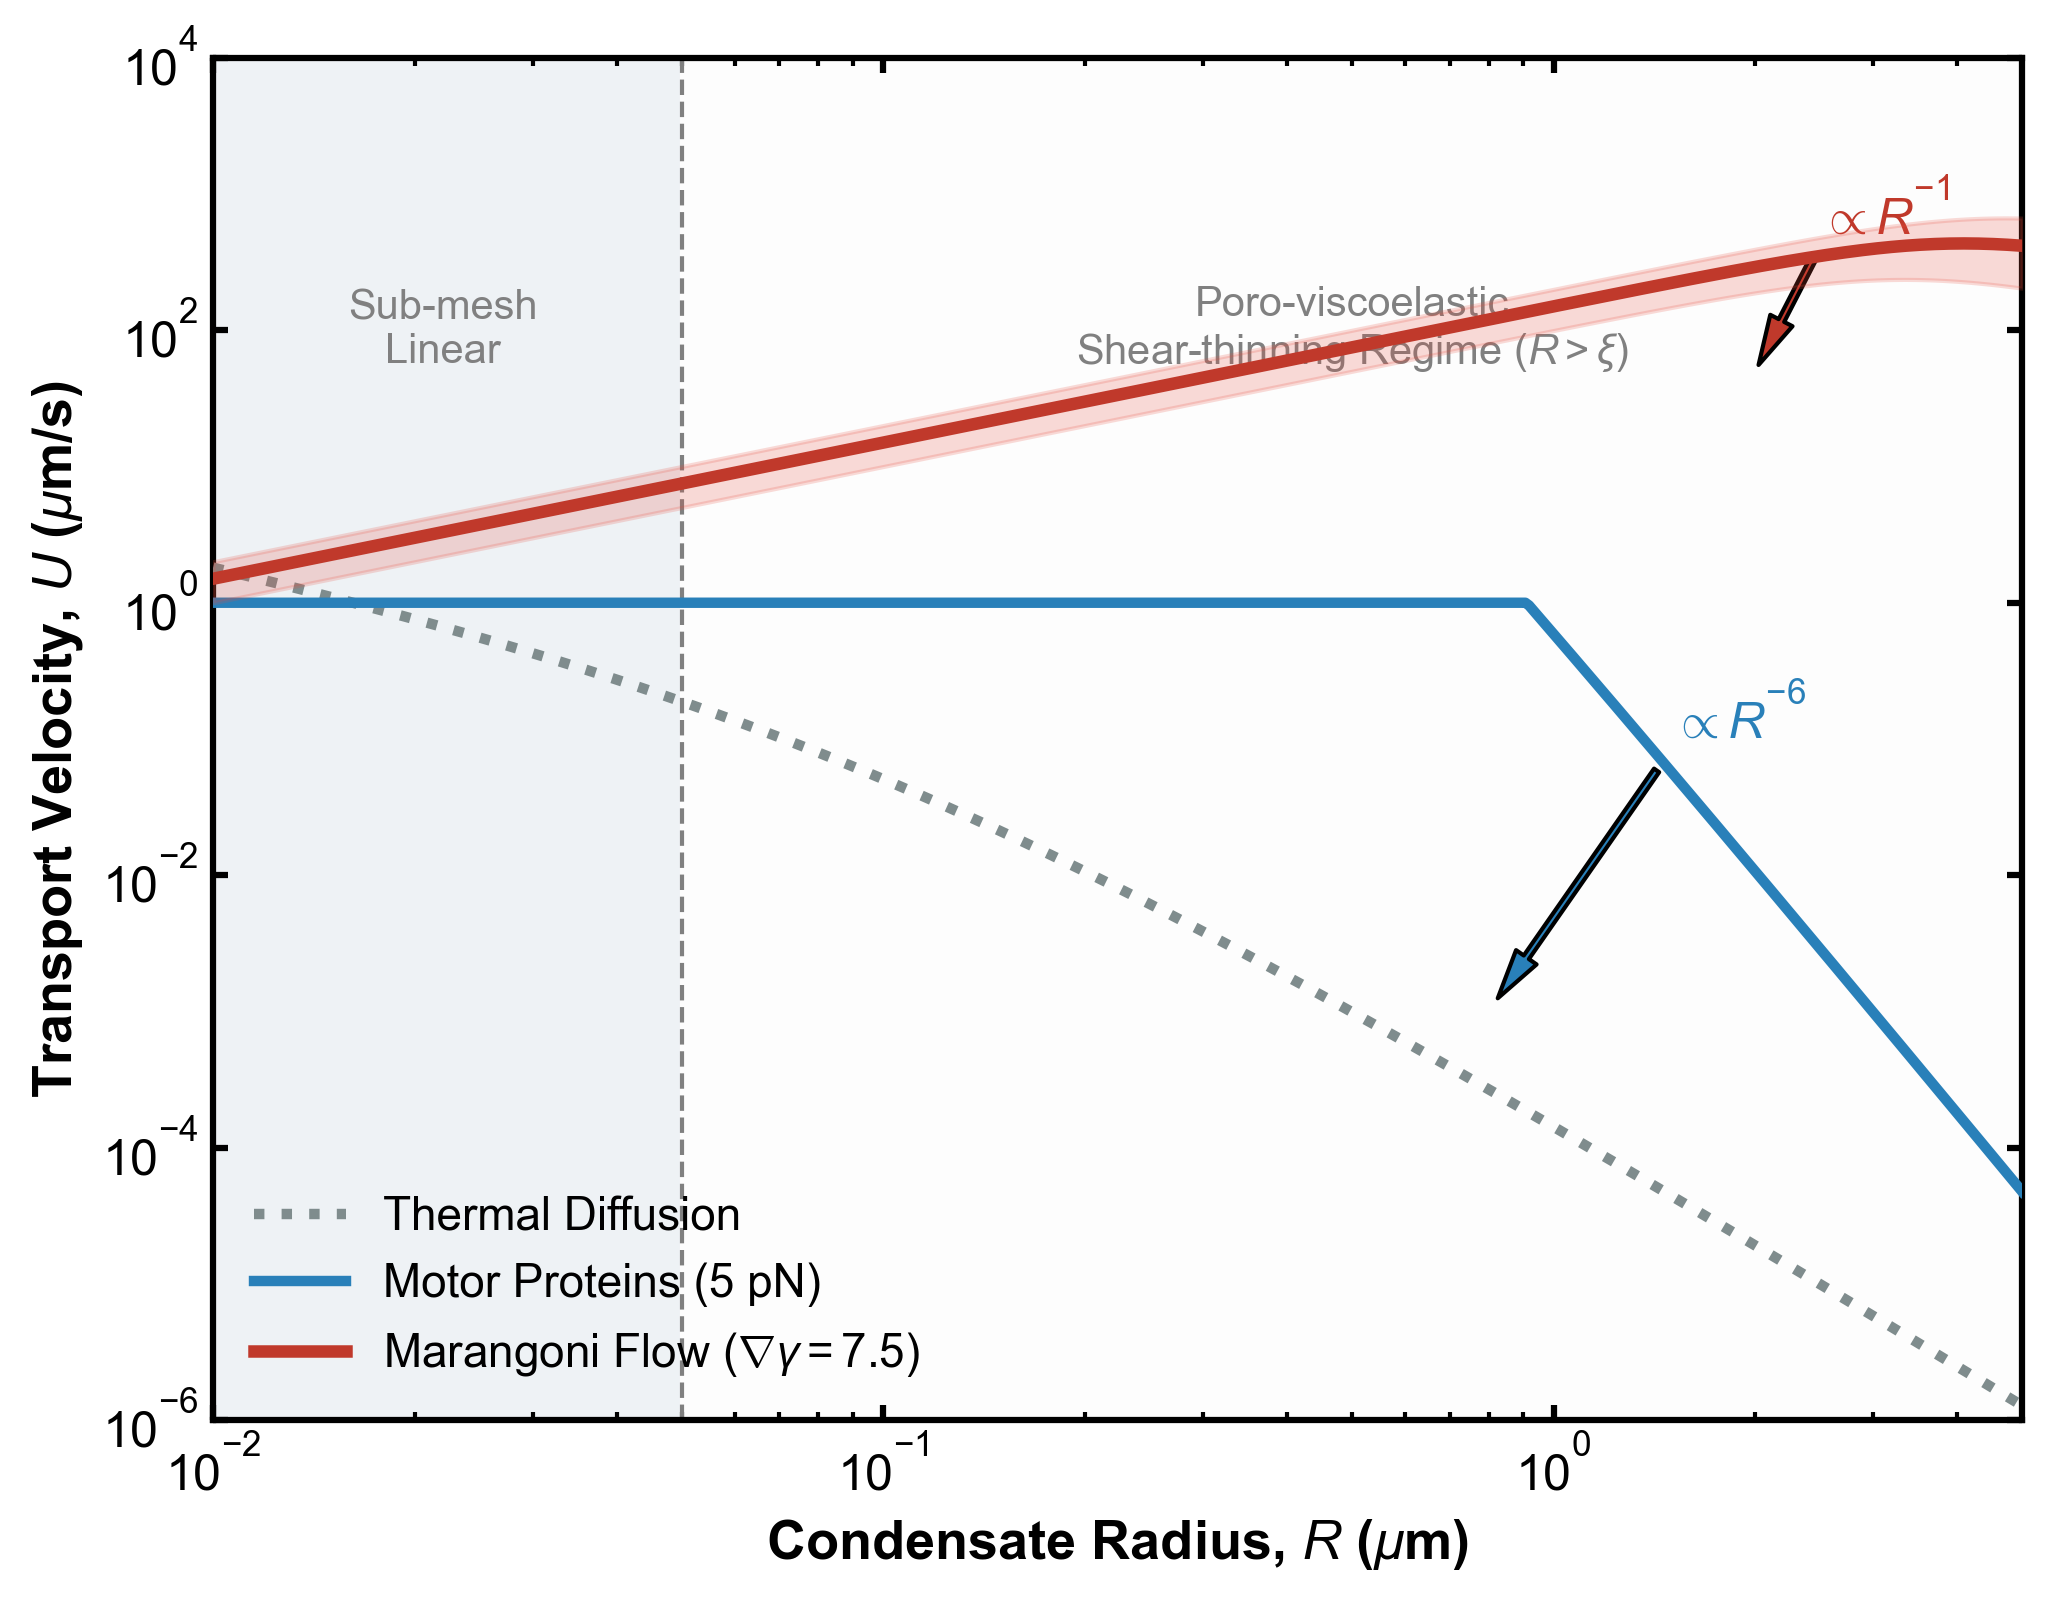

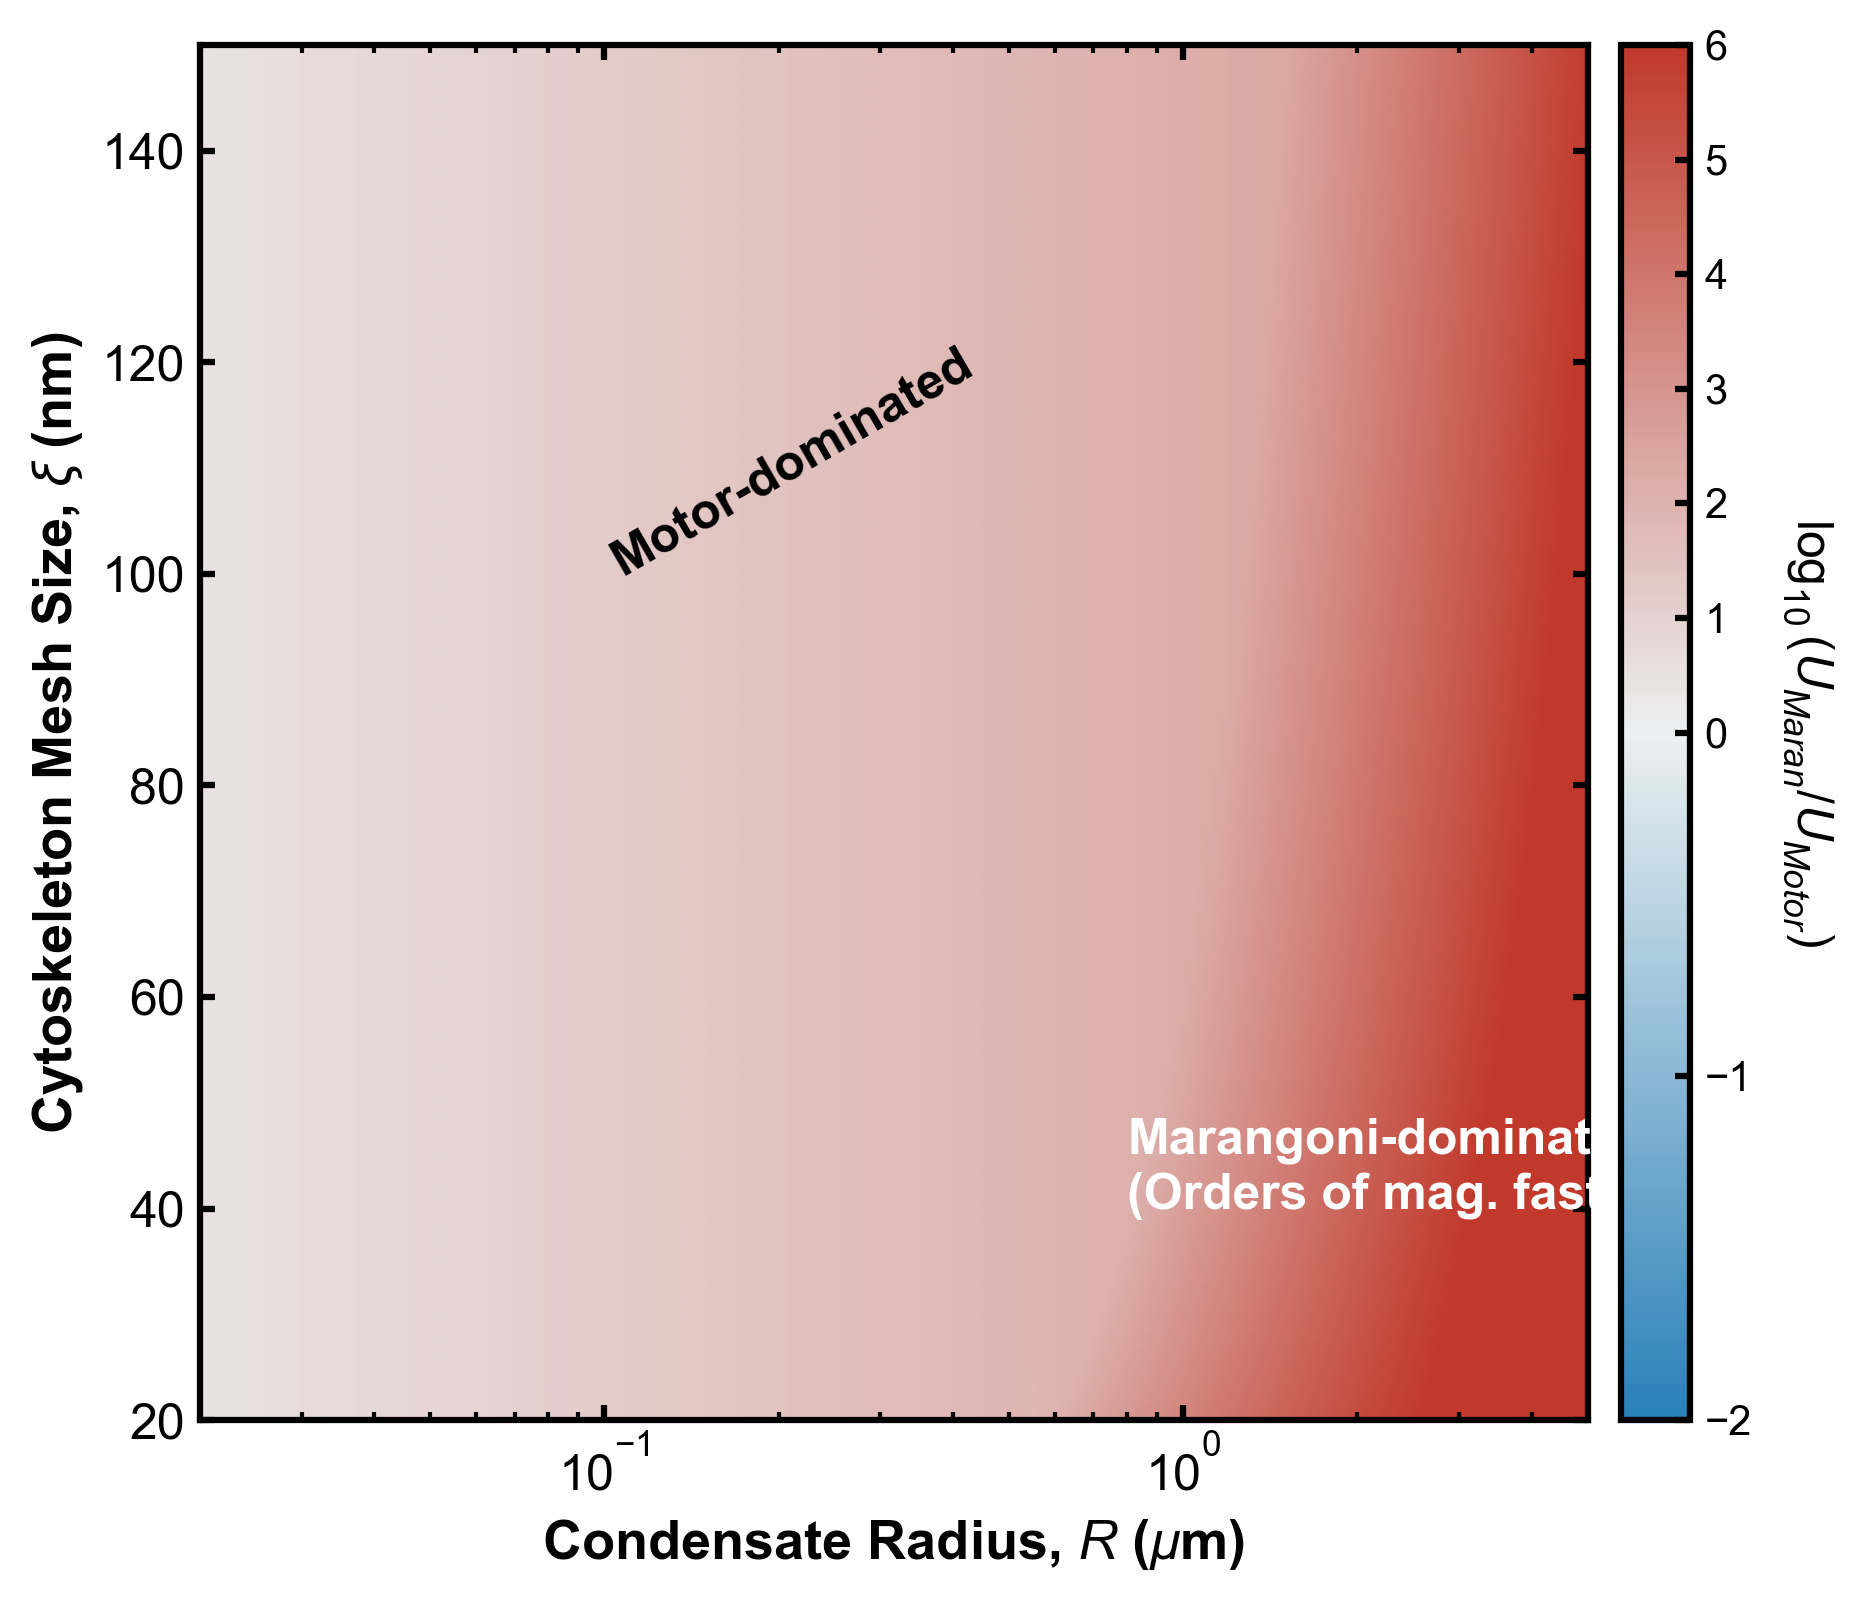

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator, NullFormatter

# ==========================================
# 1. Nature/Science Style Configuration
# ==========================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold'
})

# ==========================================
# 2. Physical Parameters
# ==========================================
n = 0.5                  # Shear-thinning index
m_visc = 0.01            # Consistency index / Base viscosity (Pa.s^n)
F_motor = 5e-12          # Motor force (5 pN)
V_max = 1e-6             # Unloaded motor speed (1 um/s)
grad_gamma_mid = 7.5     # Marangoni driving force (N/m^2)
grad_gamma_min = 5.0
grad_gamma_max = 10.0
xi_ref = 50e-9           # Reference mesh size (50 nm)
kT = 1.38e-23 * 300      # Thermal energy at 300K
L = 1e-6                 # Transport distance for diffusion eq. (1 um)
eta_in = 0.01            # Internal viscosity of condensate

beta = n**(-1 / (n + 1)) # Shear-thinning geometric factor (~1.587)

# ==========================================
# 3. Transport Velocity Functions
# ==========================================
def calc_diffusion(R, xi):
    alpha = R / xi
    # Generalized Brinkman drag
    zeta = 6 * np.pi * m_visc * R * (1 + alpha + (alpha**2)/3)
    D = kT / zeta
    return D / L

def calc_motor(R, xi):
    alpha = R / xi
    # U^n derived from F_drag = F_motor
    # F_drag = 6*pi*m*R * (1 + alpha + alpha^2/3) * (U/xi)^n * xi
    term1 = F_motor * xi**(n-1)
    term2 = 6 * np.pi * m_visc * R * (1 + alpha + (alpha**2)/3)
    U_raw = (term1 / term2)**(1/n)
    return np.minimum(U_raw, V_max)

def calc_marangoni(R, xi, grad_gamma):
    # 1. Sub-mesh Newtonian regime (Young-Goldstein-Block)
    U_stokes = (R * grad_gamma) / (2 * m_visc + 3 * eta_in)
    # 2. Poro-viscoelastic regime with shear-thinning boundary layer
    U_porous = (2 * xi**2 / (beta**2 * R)) * ((3 * grad_gamma) / (2 * m_visc))**(1/n)
    # Smooth harmonic blending
    return (U_stokes**-2 + U_porous**-2)**-0.5

# ==========================================
# 4. Plot 1: Velocity Landscape vs. Size
# ==========================================
R_array = np.logspace(np.log10(10e-9), np.log10(5e-6), 500)
R_um = R_array * 1e6

U_diff = calc_diffusion(R_array, xi_ref)
U_mot = calc_motor(R_array, xi_ref)
U_mar_mid = calc_marangoni(R_array, xi_ref, grad_gamma_mid)
U_mar_min = calc_marangoni(R_array, xi_ref, grad_gamma_min)
U_mar_max = calc_marangoni(R_array, xi_ref, grad_gamma_max)

fig1, ax1 = plt.subplots(figsize=(7, 5.5), dpi=300)

# Background shading for Regimes
ax1.axvspan(0.01, 0.05, color='#eef2f5', alpha=1.0, zorder=0)
ax1.axvspan(0.05, 5.0, color='#fdfdfd', alpha=1.0, zorder=0)
ax1.axvline(0.05, color='gray', linestyle='--', linewidth=1)
ax1.text(0.022, 1e2, 'Sub-mesh\nLinear', ha='center', va='center', fontsize=10, color='gray')
ax1.text(0.5, 1e2, 'Poro-viscoelastic\nShear-thinning Regime ($R > \\xi$)', ha='center', va='center', fontsize=10, color='gray')

# Plot lines
ax1.plot(R_um, U_diff * 1e6, color='#7f8c8d', linestyle=':', lw=2.5, label='Thermal Diffusion', zorder=3)
ax1.plot(R_um, U_mot * 1e6, color='#2980b9', linestyle='-', lw=2.5, label='Motor Proteins (5 pN)', zorder=4)
ax1.plot(R_um, U_mar_mid * 1e6, color='#c0392b', linestyle='-', lw=3, label=r'Marangoni Flow ($\nabla\gamma=7.5$)', zorder=5)
ax1.fill_between(R_um, U_mar_min * 1e6, U_mar_max * 1e6, color='#e74c3c', alpha=0.2, zorder=4)

# Annotate Scaling Laws (Slopes)
# Motor drop
ax1.annotate(r'$\propto R^{-6}$', xy=(0.8, 1e-3), xytext=(1.5, 1e-1),
             arrowprops=dict(facecolor='#2980b9', shrink=0.05, width=1.5, headwidth=6),
             fontsize=12, color='#2980b9', fontweight='bold')
# Marangoni drop
ax1.annotate(r'$\propto R^{-1}$', xy=(2.0, 50), xytext=(2.5, 500),
             arrowprops=dict(facecolor='#c0392b', shrink=0.05, width=1.5, headwidth=6),
             fontsize=12, color='#c0392b', fontweight='bold')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(0.01, 5)
ax1.set_ylim(1e-6, 1e4)
ax1.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontweight='bold', fontsize=13)
ax1.set_ylabel(r'Transport Velocity, $U$ ($\mu$m/s)', fontweight='bold', fontsize=13)
ax1.legend(loc='lower left', frameon=False, fontsize=11)
plt.tight_layout()
plt.savefig('Fig1_Transport_Landscape.pdf', bbox_inches='tight')
plt.show()

# ==========================================
# 5. Plot 2: Phase Space (R vs Mesh Size)
# ==========================================
xi_grid = np.logspace(np.log10(20e-9), np.log10(150e-9), 200)
R_grid = np.logspace(np.log10(20e-9), np.log10(5e-6), 200)
X, Y = np.meshgrid(R_grid * 1e6, xi_grid * 1e9) # um and nm for axes

Z_mar = np.zeros_like(X)
Z_mot = np.zeros_like(X)

for i in range(len(xi_grid)):
    for j in range(len(R_grid)):
        Z_mar[i, j] = calc_marangoni(R_grid[j], xi_grid[i], grad_gamma_mid)
        Z_mot[i, j] = calc_motor(R_grid[j], xi_grid[i])

# Calculate velocity ratio (Marangoni / Motor)
Z_ratio = np.log10(Z_mar / Z_mot)

fig2, ax2 = plt.subplots(figsize=(6.5, 5.5), dpi=300)
# Custom diverging colormap (Motor blue to Marangoni red)
cmap = mcolors.LinearSegmentedColormap.from_list('NatureDiv', ['#2980b9', '#ecf0f1', '#c0392b'])

# Define normalization centered at log_ratio = 0 (Velocity Equality)
norm = mcolors.TwoSlopeNorm(vmin=-2, vcenter=0, vmax=6)

pcm = ax2.pcolormesh(X, Y, Z_ratio, cmap=cmap, norm=norm, shading='gouraud')
cbar = fig2.colorbar(pcm, ax=ax2, pad=0.02)
cbar.set_label(r'$\log_{10} (U_{Maran} / U_{Motor})$', rotation=270, labelpad=20, fontweight='bold', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Draw the exact transition boundary
ax2.contour(X, Y, Z_ratio, levels=[0], colors='black', linewidths=2.5, linestyles='--')
ax2.text(0.1, 100, 'Motor-dominated', color='black', fontsize=12, fontweight='bold', rotation=30)
ax2.text(0.8, 40, 'Marangoni-dominated\n(Orders of mag. faster)', color='white', fontsize=12, fontweight='bold')

ax2.set_xscale('log')
ax2.set_xlim(0.02, 5)
ax2.set_ylim(20, 150)
ax2.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontweight='bold', fontsize=13)
ax2.set_ylabel(r'Cytoskeleton Mesh Size, $\xi$ (nm)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('Fig2_Transport_Phase_Space.pdf', bbox_inches='tight')
plt.show()

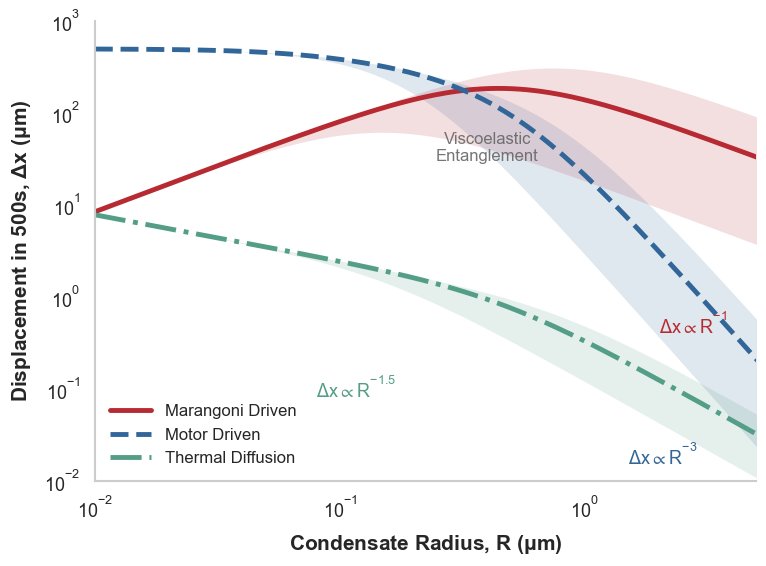

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- 1. 参数定义体系 (支持 固定值 或 [最小值, 最大值] 区间) ---
# 区间参数会自动取平均值绘制实线，取边界组合绘制阴影范围
params = {
    'eta_sol': 0.01,      # 溶剂粘度 (Pa*s)
    'xi': [15e-9, 75e-9],        # 网孔尺寸 (m)
    'G0': 200,             # 骨架弹性模量 (Pa)
    'tau': 0.1,                   # 骨架松弛时间 (s) [固定值示例]
    'grad_sigma': 5,         # 表面张力梯度 (N/m^2 or Pa)
    'N_motor': 1,                 # 恒定马达数量
    'F_stall_single': 5e-12,      # 单个马达失速力 (N)
    'v_motor_max': 1e-6,        # 马达最大速度 (m/s)
    'T': 300,          # 温度范围 (K)
    't_window': 500.0             # 观测时间窗口 (s)
}

# --- 2. 参数解析辅助函数 ---
def get_p(key, mode='mid'):
    """根据需要获取参数的中位值、最小值或最大值"""
    val = params[key]
    if isinstance(val, (list, tuple)):
        if mode == 'mid': return np.mean(val)
        elif mode == 'min': return min(val)
        elif mode == 'max': return max(val)
    return val

kB = 1.38e-23  # 玻尔兹曼常数 (J/K)
R_array = np.logspace(-8, -5, 200) # R 从 10nm (0.01um) 到 5um

# --- 3. 核心物理函数定义 ---
def drag_force(v, R, eta, xi, G0, tau):
    """综合孔隙粘弹性阻力"""
    if R >= xi:
        f_poro = 6 * np.pi * eta * (R**3 / xi**2) * v
    else:
        f_poro = 6 * np.pi * eta * R * v
    f_visco = G0 * (R**2) * (1 - np.exp(-v * tau / R))
    return f_poro + f_visco

def calc_D(R, eta, xi, G0, tau, T):
    """计算零剪切极限下的扩散系数"""
    if R >= xi:
        zeta_poro = 6 * np.pi * eta * (R**3 / xi**2)
    else:
        zeta_poro = 6 * np.pi * eta * R
    zeta_visco = G0 * R * tau
    zeta_total = zeta_poro + zeta_visco
    return kB * T / zeta_total

def get_displacements(mode='mid'):
    """
    根据模式计算位移:
    'mid': 取所有参数均值
    'fast': 取阻力最小、动力最大的边界条件
    'slow': 取阻力最大、动力最小的边界条件
    """
    # 动态调配边界条件
    if mode == 'mid':
        eta, xi_val, G0, tau = get_p('eta_sol'), get_p('xi'), get_p('G0'), get_p('tau')
        grad_s, T_val = get_p('grad_sigma'), get_p('T')
        F_stall = get_p('N_motor') * get_p('F_stall_single')
    elif mode == 'fast':
        eta, xi_val, G0, tau = get_p('eta_sol','min'), get_p('xi','max'), get_p('G0','min'), get_p('tau','min')
        grad_s, T_val = get_p('grad_sigma','max'), get_p('T','max')
        F_stall = get_p('N_motor','max') * get_p('F_stall_single','max')
    elif mode == 'slow':
        eta, xi_val, G0, tau = get_p('eta_sol','max'), get_p('xi','min'), get_p('G0','max'), get_p('tau','max')
        grad_s, T_val = get_p('grad_sigma','min'), get_p('T','min')
        F_stall = get_p('N_motor','min') * get_p('F_stall_single','min')

    v_max = get_p('v_motor_max')
    t_win = get_p('t_window')
    
    disp_maran, disp_motor, disp_diff = [], [], []
    
    for R in R_array:
        # 1. Marangoni
        drive_m = 2 * np.pi * (R**2) * grad_s
        def func_m(v): return drive_m - drag_force(v, R, eta, xi_val, G0, tau)
        try:
            v_m = brentq(func_m, 0, 10.0)
        except ValueError:
            v_m = 0.0
        disp_maran.append(v_m * t_win)
        
        # 2. Motor
        def func_motor(v):
            if v < 0: return F_stall
            if v > v_max: return -drag_force(v, R, eta, xi_val, G0, tau)
            return F_stall * (1 - v / v_max) - drag_force(v, R, eta, xi_val, G0, tau)
        try:
            v_mot = brentq(func_motor, 0, v_max)
        except ValueError:
            v_mot = 0.0
        disp_motor.append(v_mot * t_win)
        
        # 3. Diffusion (sqrt(6Dt))
        D = calc_D(R, eta, xi_val, G0, tau, T_val)
        disp_diff.append(np.sqrt(6 * D * t_win))
        
    return np.array(disp_maran), np.array(disp_motor), np.array(disp_diff)

# 运算三组数据
d_mar_mid, d_mot_mid, d_dif_mid = get_displacements('mid')
d_mar_fast, d_mot_fast, d_dif_fast = get_displacements('fast')
d_mar_slow, d_mot_slow, d_dif_slow = get_displacements('slow')

# --- 4. 高阶视觉呈现 ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

fig, ax = plt.subplots(figsize=(8, 6))

R_um = R_array * 1e6
to_um = 1e6
t_window = get_p('t_window')

# 配色设定
col_maran = '#B72A32'  # 质感红
col_motor = '#326698'  # 质感蓝
col_diff  = '#549E87'  # 质感青

# 4.1 核心优化：灰度渐变背景 (Poro-elastic 效应增强)
# 从 xi 的中位值开始渐变到作图边缘
#xi_mid_um = get_p('xi', 'mid') * 1e6
#bg_x = np.logspace(np.log10(xi_mid_um), np.log10(10), 100)
#bg_alphas = np.linspace(0, 0.5, len(bg_x)) # 最高透明度0.12，绝不喧宾夺主

#for i in range(len(bg_x)-1):
    #ax.axvspan(bg_x[i], bg_x[i+1], color='#666666', alpha=bg_alphas[i], lw=0, zorder=0)

# 4.2 绘制边界阴影区 (Z-order 设定确保不被遮挡)
ax.fill_between(R_um, d_mar_slow*to_um, d_mar_fast*to_um, color=col_maran, alpha=0.15, lw=0, zorder=1)
ax.fill_between(R_um, d_mot_slow*to_um, d_mot_fast*to_um, color=col_motor, alpha=0.15, lw=0, zorder=1)
ax.fill_between(R_um, d_dif_slow*to_um, d_dif_fast*to_um, color=col_diff, alpha=0.15, lw=0, zorder=1)

# 4.3 绘制中位实线/虚线
ax.plot(R_um, d_mar_mid*to_um, label='Marangoni Driven', color=col_maran, linewidth=3.5, zorder=2)
ax.plot(R_um, d_mot_mid*to_um, label='Motor Driven', color=col_motor, linewidth=3.5, linestyle='--', zorder=2)
ax.plot(R_um, d_dif_mid*to_um, label='Thermal Diffusion', color=col_diff, linewidth=3.5, linestyle='-.', zorder=2)

# 坐标轴与边界清理
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.01, 5)
ax.set_ylim(1e-2, 1e3)

# 核心优化：彻底去除上方和右侧边框与刻度
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.tick_params(axis='both', which='both', top=False, right=False)
ax.grid(False) # 禁用网格

# 标签与文字注记
ax.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)
ax.set_ylabel(f'Displacement in {int(t_window)}s, $\Delta x$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)
ax.tick_params(axis='both', which='major', labelsize=13, length=7)
ax.tick_params(axis='both', which='minor', length=4)

# 添加特征文字标示
ax.text(0.4, 30, 'Viscoelastic\nEntanglement', color='#666666', fontsize=12, alpha=0.9, ha='center', zorder=3)
ax.text(2.0, 0.4, r'$\Delta x \propto R^{-1}$', color=col_maran, fontsize=13)
ax.text(1.5, 0.015, r'$\Delta x \propto R^{-3}$', color=col_motor, fontsize=13)
ax.text(0.08, 0.08, r'$\Delta x \propto R^{-1.5}$', color=col_diff, fontsize=13)

# 网孔特征尺寸线
#ax.axvline(x=xi_mid_um, color='#999999', linestyle=':', linewidth=2, zorder=0)
#ax.text(xi_mid_um, 1.2e3, r'$\xi$', color='#888888', fontsize=14, ha='center', va='bottom', clip_on=False)

# 图例设定
ax.legend(loc='lower left', frameon=False, fontsize=12, handlelength=2.5)

plt.tight_layout()
plt.savefig('Displacement_Landscape_Optimized1.svg', dpi=600, bbox_inches='tight')
plt.show()

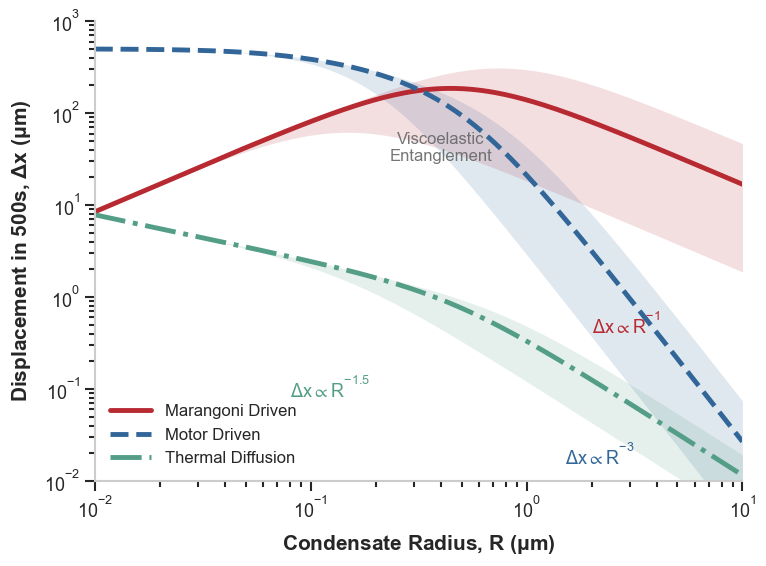

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- 1. 参数定义体系 (支持 固定值 或 [最小值, 最大值] 区间) ---
params = {
    'eta_sol': 0.01,              # 溶剂粘度 (Pa*s)
    'xi': [15e-9, 75e-9],         # 网孔尺寸 (m)
    'G0': 200,                    # 骨架弹性模量 (Pa)
    'tau': 0.1,                   # 骨架松弛时间 (s) [固定值示例]
    'grad_sigma': 5,              # 表面张力梯度 (N/m^2 or Pa)
    'N_motor': 1,                 # 恒定马达数量
    'F_stall_single': 5e-12,      # 单个马达失速力 (N)
    'v_motor_max': 1e-6,          # 马达最大速度 (m/s)
    'T': 300,                     # 温度范围 (K)
    't_window': 500.0             # 观测时间窗口 (s)
}

# --- 2. 参数解析辅助函数 ---
def get_p(key, mode='mid'):
    val = params[key]
    if isinstance(val, (list, tuple)):
        if mode == 'mid': return np.mean(val)
        elif mode == 'min': return min(val)
        elif mode == 'max': return max(val)
    return val

kB = 1.38e-23  # 玻尔兹曼常数 (J/K)
R_array = np.logspace(-8, -5, 200) # R 从 10nm (0.01um) 到 5um

# --- 3. 核心物理函数定义 ---
def drag_force(v, R, eta, xi, G0, tau):
    if R >= xi:
        f_poro = 6 * np.pi * eta * (R**3 / xi**2) * v
    else:
        f_poro = 6 * np.pi * eta * R * v
    f_visco = G0 * (R**2) * (1 - np.exp(-v * tau / R))
    return f_poro + f_visco

def calc_D(R, eta, xi, G0, tau, T):
    if R >= xi:
        zeta_poro = 6 * np.pi * eta * (R**3 / xi**2)
    else:
        zeta_poro = 6 * np.pi * eta * R
    zeta_visco = G0 * R * tau
    zeta_total = zeta_poro + zeta_visco
    return kB * T / zeta_total

def get_displacements(mode='mid'):
    if mode == 'mid':
        eta, xi_val, G0, tau = get_p('eta_sol'), get_p('xi'), get_p('G0'), get_p('tau')
        grad_s, T_val = get_p('grad_sigma'), get_p('T')
        F_stall = get_p('N_motor') * get_p('F_stall_single')
    elif mode == 'fast':
        eta, xi_val, G0, tau = get_p('eta_sol','min'), get_p('xi','max'), get_p('G0','min'), get_p('tau','min')
        grad_s, T_val = get_p('grad_sigma','max'), get_p('T','max')
        F_stall = get_p('N_motor','max') * get_p('F_stall_single','max')
    elif mode == 'slow':
        eta, xi_val, G0, tau = get_p('eta_sol','max'), get_p('xi','min'), get_p('G0','max'), get_p('tau','max')
        grad_s, T_val = get_p('grad_sigma','min'), get_p('T','min')
        F_stall = get_p('N_motor','min') * get_p('F_stall_single','min')

    v_max = get_p('v_motor_max')
    t_win = get_p('t_window')
    
    disp_maran, disp_motor, disp_diff = [], [], []
    
    for R in R_array:
        # 1. Marangoni
        drive_m = 2 * np.pi * (R**2) * grad_s
        def func_m(v): return drive_m - drag_force(v, R, eta, xi_val, G0, tau)
        try:
            v_m = brentq(func_m, 0, 10.0)
        except ValueError:
            # 修复1：使用极小正数替代 0.0，防止 log(0) 崩溃导致刻度消失
            v_m = 1e-20 
        disp_maran.append(v_m * t_win)
        
        # 2. Motor
        def func_motor(v):
            if v < 0: return F_stall
            if v > v_max: return -drag_force(v, R, eta, xi_val, G0, tau)
            return F_stall * (1 - v / v_max) - drag_force(v, R, eta, xi_val, G0, tau)
        try:
            v_mot = brentq(func_motor, 0, v_max)
        except ValueError:
            # 修复1：同上
            v_mot = 1e-20
        disp_motor.append(v_mot * t_win)
        
        # 3. Diffusion
        D = calc_D(R, eta, xi_val, G0, tau, T_val)
        disp_diff.append(np.sqrt(6 * D * t_win))
        
    return np.array(disp_maran), np.array(disp_motor), np.array(disp_diff)

d_mar_mid, d_mot_mid, d_dif_mid = get_displacements('mid')
d_mar_fast, d_mot_fast, d_dif_fast = get_displacements('fast')
d_mar_slow, d_mot_slow, d_dif_slow = get_displacements('slow')

# --- 4. 高阶视觉呈现 ---
plt.rcParams.update({
    "font.family": "sans-serif",
    # 修复2：加入 "DejaVu Sans" 作为跨平台后备字体，防止因缺少 Arial 导致标签空白
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

fig, ax = plt.subplots(figsize=(8, 6))

R_um = R_array * 1e6
to_um = 1e6
t_window = get_p('t_window')

# 配色设定
col_maran = '#B72A32'  
col_motor = '#326698'  
col_diff  = '#549E87'  

# 4.2 绘制边界阴影区 
ax.fill_between(R_um, d_mar_slow*to_um, d_mar_fast*to_um, color=col_maran, alpha=0.15, lw=0, zorder=1)
ax.fill_between(R_um, d_mot_slow*to_um, d_mot_fast*to_um, color=col_motor, alpha=0.15, lw=0, zorder=1)
ax.fill_between(R_um, d_dif_slow*to_um, d_dif_fast*to_um, color=col_diff, alpha=0.15, lw=0, zorder=1)

# 4.3 绘制中位实线/虚线
ax.plot(R_um, d_mar_mid*to_um, label='Marangoni Driven', color=col_maran, linewidth=3.5, zorder=2)
ax.plot(R_um, d_mot_mid*to_um, label='Motor Driven', color=col_motor, linewidth=3.5, linestyle='--', zorder=2)
ax.plot(R_um, d_dif_mid*to_um, label='Thermal Diffusion', color=col_diff, linewidth=3.5, linestyle='-.', zorder=2)

# 坐标轴与边界清理
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.01, 10)
ax.set_ylim(1e-2, 1e3)

# 核心优化：彻底去除上方和右侧边框与刻度
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(True)

# 修复3：显式声明 bottom=True 和 left=True，并确保 label 显示
ax.tick_params(axis='both', which='both', 
               bottom=True, top=False, 
               left=True, right=False, 
               labelbottom=True, labelleft=True)
ax.grid(False) 

# 标签与文字注记
ax.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)
ax.set_ylabel(f'Displacement in {int(t_window)}s, $\Delta x$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)
ax.tick_params(axis='both', which='major', labelsize=13, length=7)
ax.tick_params(axis='both', which='minor', length=4)

# 添加特征文字标示
ax.text(0.4, 30, 'Viscoelastic\nEntanglement', color='#666666', fontsize=12, alpha=0.9, ha='center', zorder=3)
ax.text(2.0, 0.4, r'$\Delta x \propto R^{-1}$', color=col_maran, fontsize=13)
ax.text(1.5, 0.015, r'$\Delta x \propto R^{-3}$', color=col_motor, fontsize=13)
ax.text(0.08, 0.08, r'$\Delta x \propto R^{-1.5}$', color=col_diff, fontsize=13)

ax.legend(loc='lower left', frameon=False, fontsize=12, handlelength=2.5)

plt.tight_layout()
plt.savefig('Displacement_Landscape_Optimized1.svg', dpi=600, bbox_inches='tight')
plt.show()

Calculating Data for Figure 1...
Calculating Data for Figure 2 (this may take a moment)...
Plots generated successfully with smooth transitions and enhanced labels.


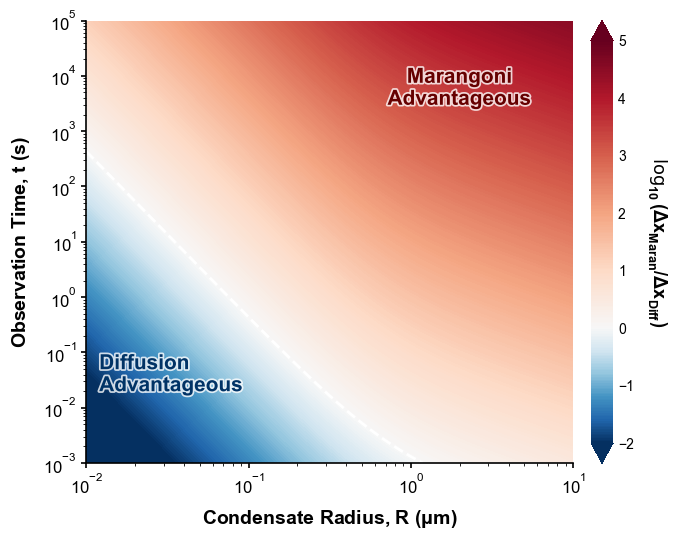

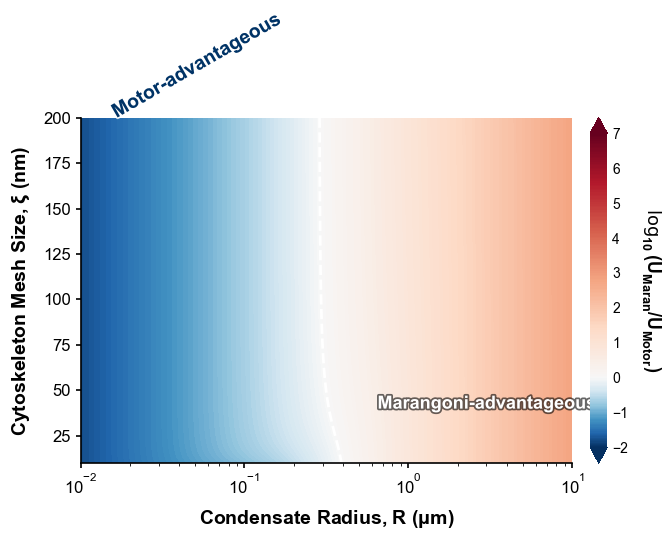

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe # 引入用于文字描边的特效库

# ==========================================
# 1. 核心物理参数定义 (国际标准单位制)
# ==========================================
eta_sol = 0.01          # 细胞质溶剂粘度 (Pa*s)
G0 = 200               # 骨架弹性模量 (Pa)
tau = 0.1              # 骨架松弛时间 (s)
grad_sigma = 5         # 表面张力梯度 (N/m^2 or Pa)
N_motor = 1            # 恒定马达数量
F_stall_single = 5e-12 # 单个马达失速力 (N)
F_stall_total = N_motor * F_stall_single
v_motor_max = 1e-6   # 马达最大速度 (m/s)

kB = 1.38e-23          # 玻尔兹曼常数 (J/K)
T_temp = 300.0         # 绝对温度 (K)

# 定义一个物理意义上的最小速度底噪，防止对数计算溢出
V_FLOOR = 1e-15 

# ==========================================
# 2. 增强数值稳定性的核心动力学求解函数
# ==========================================
def drag_force(v, R, xi):
    """涵盖多尺度效应的孔隙粘弹性阻力"""
    # 确保 v 不为负，防止指数项报错
    v_eff = np.maximum(v, 0.0)
    if R >= xi:
        f_poro = 6 * np.pi * eta_sol * (R**3 / xi**2) * v_eff
    else:
        f_poro = 6 * np.pi * eta_sol * R * v_eff
    # 添加小量防止除零
    R_eff = np.maximum(R, 1e-12)
    f_visco = G0 * (R_eff**2) * (1 - np.exp(-v_eff * tau / R_eff))
    return f_poro + f_visco

def calc_diffusion_coeff(R, xi):
    """零剪切极限下的有效扩散系数"""
    if R >= xi:
        zeta_poro = 6 * np.pi * eta_sol * (R**3 / xi**2)
    else:
        zeta_poro = 6 * np.pi * eta_sol * R
    zeta_visco = G0 * R * tau
    zeta_total = zeta_poro + zeta_visco
    return kB * T_temp / zeta_total

def get_v_maran_safe(R, xi):
    drive = 2 * np.pi * (R**2) * grad_sigma
    def func_m(v): return drive - drag_force(v, R, xi)
    
    # 检查边界条件，如果驱动力不足以克服最小阻力，返回底噪
    try:
        if func_m(V_FLOOR) < 0: return V_FLOOR
        root = brentq(func_m, V_FLOOR, 10.0) # 搜索上限设为10m/s足够大
        return np.maximum(root, V_FLOOR)
    except Exception:
        return V_FLOOR

def get_v_motor_safe(R, xi):
    def func_mot(v):
        # 物理限制区间外直接返回特定值引导求解器
        if v <= V_FLOOR: return F_stall_total - drag_force(V_FLOOR, R, xi)
        if v >= v_motor_max: return -drag_force(v_motor_max, R, xi)
        drive = F_stall_total * (1 - v / v_motor_max)
        return drive - drag_force(v, R, xi)
    
    try:
        # 检查是否这台马达根本拉不动（失速力小于静态阻力）
        if func_mot(V_FLOOR) < 0: return V_FLOOR
        root = brentq(func_mot, V_FLOOR, v_motor_max)
        return np.maximum(root, V_FLOOR)
    except Exception:
        return V_FLOOR

# ==========================================
# 3. 全局高级视觉设置 (Nature/Science Style)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "axes.linewidth": 1.2, # 稍微调细边框，更精致
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "mathtext.default": "regular" # 让公式中的字体也保持非斜体
})

# 定义文字描边特效，用于在深色背景上突出浅色文字，反之亦然
dark_text_outline = [pe.withStroke(linewidth=2.5, foreground='white', alpha=0.8)]
light_text_outline = [pe.withStroke(linewidth=2.5, foreground='black', alpha=0.6)]

# 提高计算网格密度以获得更平滑的物理场
N_GRID = 400 

# ==========================================
# 图 1: 位移比值相图 (R vs Time)
# ==========================================
R_arr1 = np.logspace(-8, -5, N_GRID)      # 10 nm to 10 um
t_arr1 = np.logspace(-3, 5, N_GRID)       # 1 ms to 100,000 s
xi_fixed = 75e-9

R_grid1, T_grid1 = np.meshgrid(R_arr1, t_arr1)
Ratio_M_vs_D = np.zeros_like(R_grid1)

print("Calculating Data for Figure 1...")
v_maran_arr1 = np.array([get_v_maran_safe(r, xi_fixed) for r in R_arr1])
D_arr1 = np.array([calc_diffusion_coeff(r, xi_fixed) for r in R_arr1])

# 利用广播机制高效计算
disp_M_grid = v_maran_arr1[np.newaxis, :] * T_grid1
disp_D_grid = np.sqrt(6 * D_arr1[np.newaxis, :] * T_grid1)
Ratio_M_vs_D = disp_M_grid / np.maximum(disp_D_grid, V_FLOOR*1e-3) # 防止除零

log_ratio1 = np.log10(Ratio_M_vs_D)

# --- 绘图 1 ---
fig1, ax1 = plt.subplots(figsize=(7, 5.5))

# 设置色标范围和中心
vmin1, vmax1 = -2, 5
norm1 = mcolors.TwoSlopeNorm(vmin=vmin1, vcenter=0, vmax=vmax1)
cmap_coolwarm = plt.get_cmap('RdBu_r')
# 使用足够多的色阶层数 (levels=256) 来模拟连续平滑过渡
levels1 = np.linspace(vmin1, vmax1, 256)

# 核心改进：使用 contourf 代替 pcolormesh 实现丝滑平滑
cf1 = ax1.contourf(R_grid1 * 1e6, T_grid1, log_ratio1, levels=levels1, cmap=cmap_coolwarm, norm=norm1, extend='both')

# 绘制等分界线 (Ratio = 1)
CS1 = ax1.contour(R_grid1 * 1e6, T_grid1, log_ratio1, levels=[0], colors='white', linewidths=2, linestyles='--')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.tick_params(top=False, right=False, which='both')

ax1.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontsize=14, fontweight='bold', labelpad=8)
ax1.set_ylabel(r'Observation Time, $t$ (s)', fontsize=14, fontweight='bold', labelpad=8)
ax1.tick_params(labelsize=12)

# 色标条优化
cbar1 = fig1.colorbar(cf1, ax=ax1, pad=0.03, ticks=np.arange(vmin1, vmax1+1))
cbar1.set_label(r'$\log_{10}(\Delta x_{Maran} / \Delta x_{Diff})$', fontsize=13, fontweight='bold', rotation=270, labelpad=25)
cbar1.outline.set_visible(False) # 去掉色标边框更现代
cbar1.ax.tick_params(length=0) # 去掉色标刻度线

# 区域说明文字 (应用描边特效)
ax1.text(0.012, 2e-2, 'Diffusion\nAdvantageous', color='#003366', fontsize=15, fontweight='bold', ha='left', path_effects=dark_text_outline)
ax1.text(2.0, 3e3, 'Marangoni\nAdvantageous', color='#660000', fontsize=15, fontweight='bold', ha='center', path_effects=dark_text_outline)

plt.tight_layout()
plt.savefig('Fig1_Smooth_Time_vs_Radius.svg', dpi=600, bbox_inches='tight')


# ==========================================
# 图 2: 速度比值相图 (R vs Mesh Size)
# ==========================================
R_arr2 = np.logspace(-8, -5, N_GRID)       # 10 nm to 10 um
xi_arr2 = np.linspace(10e-9, 200e-9, N_GRID) # 10 nm to 200 nm

R_grid2, Xi_grid2 = np.meshgrid(R_arr2, xi_arr2)
Ratio_M_vs_Mot = np.zeros_like(R_grid2)

print("Calculating Data for Figure 2 (this may take a moment)...")
# 需要双重循环计算每个网格点的物理状态
for i in range(N_GRID):
    for j in range(N_GRID):
        r_val = R_arr2[j]
        xi_val = xi_arr2[i]
        v_mar = get_v_maran_safe(r_val, xi_val)
        v_mot = get_v_motor_safe(r_val, xi_val)
        Ratio_M_vs_Mot[i, j] = v_mar / v_mot

log_ratio2 = np.log10(Ratio_M_vs_Mot)

# --- 绘图 2 ---
fig2, ax2 = plt.subplots(figsize=(7, 5.5))

# 设置色标范围，右下角区域比值极大，适当提高 vmax
vmin2, vmax2 = -2, 7 
norm2 = mcolors.TwoSlopeNorm(vmin=vmin2, vcenter=0, vmax=vmax2)
levels2 = np.linspace(vmin2, vmax2, 256) # 平滑过渡的关键

# 使用 contourf 实现平滑
cf2 = ax2.contourf(R_grid2 * 1e6, Xi_grid2 * 1e9, log_ratio2, levels=levels2, cmap=cmap_coolwarm, norm=norm2, extend='both')

# 绘制等分界线
CS2 = ax2.contour(R_grid2 * 1e6, Xi_grid2 * 1e9, log_ratio2, levels=[0], colors='white', linewidths=2, linestyles='--')

ax2.set_xscale('log')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.tick_params(top=False, right=False, which='both')

ax2.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontsize=14, fontweight='bold', labelpad=8)
ax2.set_ylabel(r'Cytoskeleton Mesh Size, $\xi$ (nm)', fontsize=14, fontweight='bold', labelpad=8)
ax2.tick_params(labelsize=12)

# 色标条优化
cbar2 = fig2.colorbar(cf2, ax=ax2, pad=0.03, ticks=np.arange(vmin2, vmax2+1))
cbar2.set_label(r'$\log_{10}(U_{Maran} / U_{Motor})$', fontsize=13, fontweight='bold', rotation=270, labelpad=25)
cbar2.outline.set_visible(False)
cbar2.ax.tick_params(length=0)

# 区域说明文字 (应用描边特效，确保在深红/深蓝背景下清晰可见)
# 在蓝色区域用深色字加白边
ax2.text(0.015, 200, 'Motor-advantageous', color='#003366', fontsize=14, fontweight='bold', rotation=30, path_effects=dark_text_outline)
# 在深红色区域用浅色字加黑边，看起来更自然
ax2.text(3.0, 40, 'Marangoni-advantageous', color='white', fontsize=13, fontweight='bold', ha='center', path_effects=light_text_outline)

plt.tight_layout()
plt.savefig('Fig2_Smooth_Mesh_vs_Radius.svg', dpi=600, bbox_inches='tight')

print("Plots generated successfully with smooth transitions and enhanced labels.")
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_1164\1124357411.py:37: RuntimeWarning: invalid value encountered in divide
  Cos_q = Z_q / R_q
C:\Users\dell\AppData\Local\Temp\ipykernel_1164\1124357411.py:38: RuntimeWarning: invalid value encountered in divide
  Sin_q = Y_q / R_q
C:\Users\dell\AppData\Local\Temp\ipykernel_1164\1124357411.py:41: RuntimeWarning: divide by zero encountered in divide
  Uz_q = (1/R_q**3 - 1)*Cos_q**2 - (0.5/R_q**3 + 1)*Sin_q**2
C:\Users\dell\AppData\Local\Temp\ipykernel_1164\1124357411.py:42: RuntimeWarning: divide by zero encountered in divide
  Uy_q = (1.5/R_q**3) * Sin_q * Cos_q


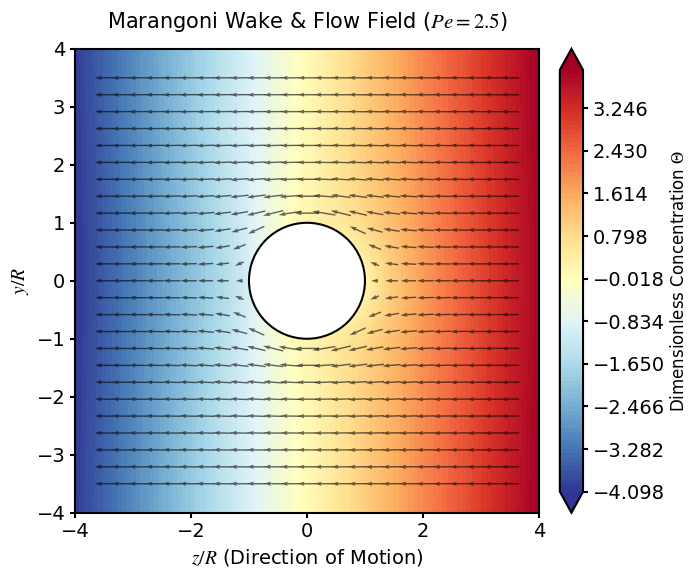

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle

# ==========================================
# 图像一：稳态 Marangoni 尾迹流场与浓度场
# ==========================================
def plot_concentration_flow_field():
    # 物理参数
    Pe = 2.5 # 选择一个中等Peclet数以展现明显的尾迹但保持摄动解稳定
    beta = 19.0 / 288.0
    
    # 空间网格划分 (液滴半径 R=1，域大小为 [-4, 4])
    y = np.linspace(-4, 4, 400)
    z = np.linspace(-4, 4, 400)
    Y, Z = np.meshgrid(y, z)
    R_grid = np.sqrt(Y**2 + Z**2)
    CosTheta = Z / R_grid
    SinTheta = Y / R_grid
    
    # 掩码：隐藏液滴内部 (r < 1)
    mask = R_grid >= 1.0
    
    # 1. 计算浓度场 (截取二阶精确解)
    P1 = CosTheta
    P2 = 0.5 * (3 * CosTheta**2 - 1)
    Theta = R_grid * P1 - Pe * (1 / (6 * R_grid)) * P2 - (Pe**2) * (beta / R_grid**3) * P1
    Theta = np.ma.masked_where(~mask, Theta)
    
    # 2. 计算流场 (用于绘制矢量箭头)
    # 为了箭头清晰，使用较稀疏的网格
    y_q = np.linspace(-3.5, 3.5, 25)
    z_q = np.linspace(-3.5, 3.5, 25)
    Y_q, Z_q = np.meshgrid(y_q, z_q)
    R_q = np.sqrt(Y_q**2 + Z_q**2)
    Cos_q = Z_q / R_q
    Sin_q = Y_q / R_q
    mask_q = R_q >= 1.1 # 留出一点界面边界
    
    Uz_q = (1/R_q**3 - 1)*Cos_q**2 - (0.5/R_q**3 + 1)*Sin_q**2
    Uy_q = (1.5/R_q**3) * Sin_q * Cos_q
    
    Uz_q = np.ma.masked_where(~mask_q, Uz_q)
    Uy_q = np.ma.masked_where(~mask_q, Uy_q)

    # 绘制
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 等浓度线填色 (使用冷暖色调代表浓度高低)
    levels = np.linspace(np.min(Theta), np.max(Theta), 100)
    cmap = plt.get_cmap('RdYlBu_r')
    cf = ax.contourf(Z, Y, Theta, levels=levels, cmap=cmap, extend='both')
    
    # 添加流场矢量箭头
    ax.quiver(Z_q, Y_q, Uz_q, Uy_q, color='black', alpha=0.6, pivot='mid', scale=25, width=0.003)
    
    # 画出液滴本体 (白色圆)
    drop = Circle((0, 0), 1.0, color='white', zorder=10, ec='black', lw=1.5)
    ax.add_patch(drop)
    
    # 图像修饰
    ax.set_aspect('equal')
    ax.set_xlabel(r'$z / R$ (Direction of Motion)', fontsize=14)
    ax.set_ylabel(r'$y / R$', fontsize=14)
    ax.set_title(fr'Marangoni Wake & Flow Field ($Pe = {Pe}$)', fontsize=15, pad=15)
    cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'Dimensionless Concentration $\Theta$', fontsize=12)
    
    plt.tight_layout()
    # 保存为 600dpi 高清矢量图
    plt.savefig(f'Marangoni_Wake_Field_Pe_{Pe}.svg', format='svg', dpi=600, bbox_inches='tight')
    plt.show()

# ==========================================
# 图像二：动力学标度律指数 \alpha 随 Pe 的连续演化
# ==========================================
def plot_alpha_evolution():
    # 设定 Pe 数范围 (0.01 到 100, 对数分布)
    Pe = np.logspace(-2, 2, 500)
    beta = 19.0 / 288.0
    
    # 根据严谨推导的全域连续函数计算 \alpha
    alpha = (1 + 2 * beta * Pe**2) / (1 + 6 * beta * Pe**2)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # 绘制主曲线
    ax.semilogx(Pe, alpha, color='#D32F2F', lw=3, label=r'$\alpha(Pe) = \frac{1 + 2\beta Pe^2}{1 + 6\beta Pe^2}$')
    
    # 绘制物理极限渐近线 (作为参考基准)
    ax.axhline(y=1.0, color='gray', linestyle='--', lw=1.5, alpha=0.7, label=r'Diffusion Limit ($\alpha = 1$)')
    ax.axhline(y=1/3, color='blue', linestyle='--', lw=1.5, alpha=0.7, label=r'Convection Limit ($\alpha = 1/3$)')
    
    # 图像修饰
    ax.set_xlabel(r'Peclet Number ($Pe = UR/D$)', fontsize=14)
    ax.set_ylabel(r'Scaling Exponent $\alpha$', fontsize=14)
    ax.set_title(r'Evolution of Power-Law Exponent ($v \sim R^\alpha$) over $Pe$', fontsize=15, pad=15)
    
    # 坐标轴限制与刻度
    ax.set_ylim(0.2, 1.1)
    ax.set_xlim(1e-2, 1e2)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    
    # 图例配置
    ax.legend(fontsize=12, loc='upper right', framealpha=0.9, edgecolor='black')
    
    plt.tight_layout()
    # 保存为 600dpi 高清矢量图
    plt.savefig('Alpha_Evolution.svg', format='svg', dpi=600, bbox_inches='tight')
    plt.show()

# 执行绘图函数
plot_concentration_flow_field()
#plot_alpha_evolution()

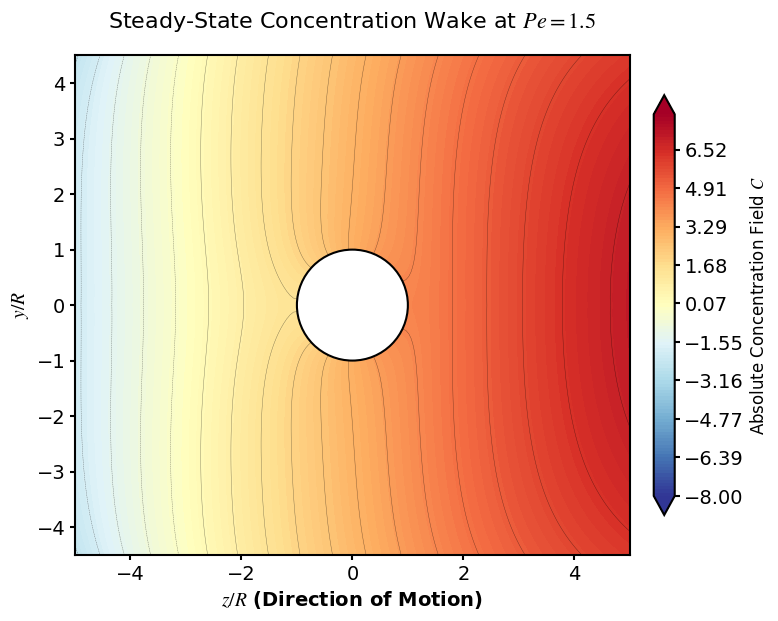

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_rigorous_marangoni_wake(Pe=1, R_max=8.0, N=100, iters=8000):
    # 1. 构建极坐标网格 (为避免极点cot(0)除零错误，稍微偏移极角)
    r = np.linspace(1.0, R_max, N)
    theta = np.linspace(1e-4, np.pi - 1e-4, N)
    R, Theta = np.meshgrid(r, theta, indexing='ij')

    dr = r[1] - r[0]
    dtheta = theta[1] - theta[0]

    # 2. 预计算无量纲速度场
    Ur = (1.0/R**3 - 1.0) * np.cos(Theta)
    Utheta = (0.5/R**3 + 1.0) * np.sin(Theta)

    # 3. 初始化浓度场为背景均匀梯度
    C = R * np.cos(Theta)

    # 4. 设定稳定的伪瞬态时间步长 (满足 CFL 与扩散稳定条件)
    dt_diff = 0.25 * min(dr**2, dtheta**2)
    max_vel = max(np.max(np.abs(Ur)), np.max(np.abs(Utheta)))
    dt_adv = 0.5 * dr / (Pe * max_vel + 1e-10)
    dt = min(dt_diff, dt_adv)

    # 5. 偏微分方程迎风弛豫迭代求解
    for _ in range(iters):
        # 提取内部节点
        C_in = C[1:-1, 1:-1]
        R_in = R[1:-1, 1:-1]
        T_in = Theta[1:-1, 1:-1]
        Ur_in = Ur[1:-1, 1:-1]
        Ut_in = Utheta[1:-1, 1:-1]
        
        # --- 扩散项 (二阶中心差分) ---
        Lap_r = (C[2:, 1:-1] - 2*C_in + C[:-2, 1:-1]) / dr**2 + \
                (2.0 / R_in) * (C[2:, 1:-1] - C[:-2, 1:-1]) / (2*dr)
                
        Lap_t = (1.0 / R_in**2) * (C[1:-1, 2:] - 2*C_in + C[1:-1, :-2]) / dtheta**2 + \
                (1.0 / np.tan(T_in) / R_in**2) * (C[1:-1, 2:] - C[1:-1, :-2]) / (2*dtheta)

        # --- 对流项 (一阶物理迎风差分) ---
        # 径向迎风
        C_r_fw = (C[2:, 1:-1] - C_in) / dr
        C_r_bw = (C_in - C[:-2, 1:-1]) / dr
        Adv_r = Pe * np.where(Ur_in > 0, Ur_in * C_r_bw, Ur_in * C_r_fw)
        
        # 切向迎风
        C_t_fw = (C[1:-1, 2:] - C_in) / dtheta
        C_t_bw = (C_in - C[1:-1, :-2]) / dtheta
        Adv_t = Pe * (Ut_in / R_in) * np.where(Ut_in > 0, C_t_bw, C_t_fw)

        # --- 演化更新 ---
        C[1:-1, 1:-1] += dt * (Lap_r + Lap_t - Adv_r - Adv_t)

        # --- 强制边界条件 ---
        C[-1, :] = R[-1, :] * np.cos(Theta[-1, :])  # 远场: Dirichlet边界
        C[0, :] = C[1, :]                           # 表面: 无通量 Neumann边界
        C[:, 0] = C[:, 1]                           # 极轴: 对称边界
        C[:, -1] = C[:, -2]

    # 6. 将结果映射至二维笛卡尔坐标系并镜像对称生成完整液滴
    Z_half = R * np.cos(Theta)
    Y_half = R * np.sin(Theta)
    
    # 拼接左右半球
    Z_full = np.hstack([Z_half, Z_half[:, ::-1]])
    Y_full = np.hstack([Y_half, -Y_half[:, ::-1]])
    C_full = np.hstack([C, C[:, ::-1]])

    # 7. 高清绘图渲染
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # 设定浓度颜色映射，使用 RdYlBu_r 强调高低对比
    levels = np.linspace(-R_max, R_max, 120)
    cf = ax.contourf(Z_full, Y_full, C_full, levels=levels, cmap='RdYlBu_r', extend='both')
    
    # 叠加等高线以明确空间梯度变化
    contour_levels = np.linspace(-R_max, R_max, 30)
    ax.contour(Z_full, Y_full, C_full, levels=contour_levels, colors='black', linewidths=0.3, alpha=0.5)

    # 绘制液滴实体
    drop = Circle((0, 0), 1.0, color='white', zorder=10, ec='black', lw=1.5)
    ax.add_patch(drop)

    # 图像比例与标签修饰
    ax.set_aspect('equal')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_xlabel(r'$z / R$ (Direction of Motion)', fontsize=14, fontweight='bold')
    ax.set_ylabel(r'$y / R$', fontsize=14, fontweight='bold')
    ax.set_title(fr'Steady-State Concentration Wake at $Pe = {Pe}$', fontsize=16, pad=20)
    
    cbar = fig.colorbar(cf, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label(r'Absolute Concentration Field $C$', fontsize=12)

    plt.tight_layout()
    # 输出 600dpi 高清矢量图
    plt.savefig(f'Rigorous_Marangoni_Wake_Pe_{Pe}.svg', format='svg', dpi=600, bbox_inches='tight')
    plt.show()

# 运行计算与绘图 (约需数秒至十秒计算时间)
plot_rigorous_marangoni_wake(Pe=1.5)